# Notebook 2: Document Validation, Text Extraction and Preprocessing

## In this notebook, I will carry out the following activities

- Load the downloaded-report dataset produced in Notebook 1.
- Confirm that each recorded PDF exists in the report folder.
- Validate PDF integrity, readability and duplicate hashes.
- Extract and permanently save one text file for each company.
- Calculate page, character and word counts.
- Apply the minimum eligibility requirement of 5,000 extracted words.
- Clean, tokenise and lemmatise the eligible report text.
- Permanently save the processed text files.
- Examine the sector distribution of usable reports.
- Select the final 100 companies using proportionate stratified sampling.
- Export the final text dataset required for Notebook 3.

**Input file:** `Notebook02_Report_Validation_Input.xlsx`  
**PDF folder:** `report/original_reports`  
**Extracted-text folder:** `report/extracted_text`  
**Processed-text folder:** `report/processed_text`  
**Minimum report length:** 5,000 words  
**Final sample:** 100 companies  
**Fixed random seed:** 42

## 1. Set Up the Project Folders and Core Libraries

I imported the core libraries and defined the project-folder locations. Extracted and processed report text will be saved permanently in separate folders rather than being retained only in notebook memory.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import re

SEED = 42
PROJECT_COLOUR = "#1F4E78"

PROJECT_FOLDER = Path.home() / "Desktop" / "ESGProjectAnalysis"

DATA_FOLDER = PROJECT_FOLDER / "data"
OUTPUT_FOLDER = PROJECT_FOLDER / "output"
REPORT_FOLDER = PROJECT_FOLDER / "report"

ORIGINAL_REPORT_FOLDER = REPORT_FOLDER / "original_reports"
EXTRACTED_TEXT_FOLDER = REPORT_FOLDER / "extracted_text"
PROCESSED_TEXT_FOLDER = REPORT_FOLDER / "processed_text"

for folder in [
    DATA_FOLDER,
    OUTPUT_FOLDER,
    EXTRACTED_TEXT_FOLDER,
    PROCESSED_TEXT_FOLDER
]:
    folder.mkdir(parents=True, exist_ok=True)

if not ORIGINAL_REPORT_FOLDER.exists():
    raise FileNotFoundError(
        f"Original report folder not found: {ORIGINAL_REPORT_FOLDER}"
    )

print(f"Project folder: {PROJECT_FOLDER}")
print(f"PDF folder: {ORIGINAL_REPORT_FOLDER}")
print(f"Extracted-text folder: {EXTRACTED_TEXT_FOLDER}")
print(f"Processed-text folder: {PROCESSED_TEXT_FOLDER}")

Project folder: C:\Users\HP\Desktop\ESGProjectAnalysis
PDF folder: C:\Users\HP\Desktop\ESGProjectAnalysis\report\original_reports
Extracted-text folder: C:\Users\HP\Desktop\ESGProjectAnalysis\report\extracted_text
Processed-text folder: C:\Users\HP\Desktop\ESGProjectAnalysis\report\processed_text


## 2. Load the Downloaded-Report Dataset

I loaded the report-validation dataset produced in Notebook 1. It contains one successfully downloaded report record for each company.

In [2]:
input_file = DATA_FOLDER / "Notebook02_Report_Validation_Input.xlsx"

if not input_file.exists():
    raise FileNotFoundError(f"Input file not found: {input_file}")

reports_df = pd.read_excel(input_file)

print(f"Reports loaded: {len(reports_df)}")
print(f"Dataset shape: {reports_df.shape}")

display(reports_df.head())

Reports loaded: 116
Dataset shape: (116, 15)


,Sample ID,RIC,Company Name,Company Website,Market Cap,TRBC Sector,LSEG ESG Score,Report URL,Report Year,Report Type,Downloaded Filename,File Path,File Size Bytes,SHA256,Download Status
0,FTSE-001,ATYM.L,Atalaya Mining Copper SA,https://atalayamining.com,1.395645e+09,Basic Materials,3.033797,https://wp-atalaya-mining-2022.s3.eu-west-2.am...,2025,Annual Report,FTSE-001_Atalaya_Mining_Copper_SA_2025.pdf,C:\Users\HP\Desktop\ESGProjectAnalysis\report\...,32221841,2a562199f3259c9d7a55aa87d13a8b2630615b7ebe3a32...,Downloaded
1,FTSE-003,CRDA.L,Croda International PLC,https://www.croda.com,4.094183e+09,Basic Materials,3.686486,https://www.croda.com/mediaassets/files/corpor...,2025,Annual Report,FTSE-003_Croda_International_PLC_2025.pdf,C:\Users\HP\Desktop\ESGProjectAnalysis\report\...,15338620,a4a2b498b765a3c674b08d8c043ef520c60b81890a98f9...,Downloaded
2,FTSE-004,GLEN.L,Glencore PLC,https://www.glencore.com,6.107874e+10,Basic Materials,3.812741,https://www.glencore.com/.rest/api/v1/document...,2025,Annual Report,FTSE-004_Glencore_PLC_2025.pdf,C:\Users\HP\Desktop\ESGProjectAnalysis\report\...,8429333,5c1a900adb8fa20291b38b81664a879d035a495c1d88de...,Downloaded
3,FTSE-005,HILS.L,Hill & Smith PLC,https://hsgroup.com,2.351415e+09,Basic Materials,2.492386,https://hsgroup.com/media/jprf2zd5/annual-repo...,2025,Annual Report,FTSE-005_Hill_Smith_PLC_2025.pdf,C:\Users\HP\Desktop\ESGProjectAnalysis\report\...,8220558,f58e1f4914fe34e01ab4713393a9fb089095de07506166...,Downloaded
4,FTSE-006,MNDI.L,Mondi PLC,https://www.mondigroup.com,3.330964e+09,Basic Materials,3.625000,https://www.mondigroup.com/globalassets/mondig...,2023,Annual Report,FTSE-006_Mondi_PLC_2023.pdf,C:\Users\HP\Desktop\ESGProjectAnalysis\report\...,13809697,bb25d6f5ee3c7e92cfe37e197e9073fc75cc98880ab4ba...,Downloaded


## 3. Validate the Dataset and Rebuild the PDF Paths

I confirmed that all required variables were available and rebuilt each PDF location from the current project folder. This avoids relying on old absolute file paths stored during Notebook 1.



In [3]:
required_columns = [
    "Sample ID",
    "RIC",
    "Company Name",
    "Market Cap",
    "TRBC Sector",
    "LSEG ESG Score",
    "Report Year",
    "Report Type",
    "Downloaded Filename",
    "SHA256"
]

missing_columns = [
    column for column in required_columns
    if column not in reports_df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Rebuild the PDF paths from the current project folder
reports_df["PDF Path"] = reports_df["Downloaded Filename"].apply(
    lambda filename: str(ORIGINAL_REPORT_FOLDER / str(filename))
)

reports_df["File Exists"] = reports_df["PDF Path"].apply(
    lambda path: Path(path).exists()
)

initial_audit = pd.DataFrame({
    "Validation Check": [
        "Report records",
        "Missing essential values",
        "Duplicate companies",
        "Duplicate PDF hashes",
        "Missing PDF files"
    ],
    "Result": [
        len(reports_df),
        reports_df[required_columns].isna().sum().sum(),
        reports_df["Company Name"].duplicated().sum(),
        reports_df["SHA256"].duplicated().sum(),
        (~reports_df["File Exists"]).sum()
    ]
})

display(initial_audit.style.hide(axis="index"))

Validation Check,Result
Report records,116
Missing essential values,0
Duplicate companies,0
Duplicate PDF hashes,0
Missing PDF files,0


## 4. Validate PDF Integrity and File Hashes

I independently checked each downloaded file for a valid PDF header, completion marker, minimum file size and SHA-256 hash. This confirmed that the files were complete and identified any duplicate PDF content.

In [8]:
pdf_check_columns = [
    "Actual File Size",
    "Actual SHA256",
    "PDF Header Valid",
    "PDF Complete",
    "Integrity Status"
]

# Remove results from any previous incomplete run
reports_df = reports_df.drop(
    columns=pdf_check_columns,
    errors="ignore"
)


def inspect_pdf(pdf_path):
    pdf_path = Path(pdf_path)

    if not pdf_path.exists():
        return {
            "Actual File Size": 0,
            "Actual SHA256": "",
            "PDF Header Valid": False,
            "PDF Complete": False,
            "Integrity Status": "Missing File"
        }

    try:
        file_hash = hashlib.sha256()

        with pdf_path.open("rb") as pdf_file:
            header = pdf_file.read(5)

            pdf_file.seek(0)
            for block in iter(
                lambda: pdf_file.read(1024 * 1024),
                b""
            ):
                file_hash.update(block)

            pdf_file.seek(
                max(0, pdf_path.stat().st_size - 10_000)
            )
            ending = pdf_file.read()

        file_size = pdf_path.stat().st_size
        header_valid = header == b"%PDF-"
        complete = b"%%EOF" in ending

        valid = (
            file_size >= 50_000
            and header_valid
            and complete
        )

        return {
            "Actual File Size": file_size,
            "Actual SHA256": file_hash.hexdigest(),
            "PDF Header Valid": header_valid,
            "PDF Complete": complete,
            "Integrity Status": "Valid" if valid else "Invalid"
        }

    except Exception:
        return {
            "Actual File Size": 0,
            "Actual SHA256": "",
            "PDF Header Valid": False,
            "PDF Complete": False,
            "Integrity Status": "Invalid"
        }


pdf_checks = pd.DataFrame(
    [
        inspect_pdf(pdf_path)
        for pdf_path in reports_df["PDF Path"]
    ],
    index=reports_df.index
)

reports_df = pd.concat(
    [reports_df, pdf_checks],
    axis=1
)

integrity_summary = (
    reports_df["Integrity Status"]
    .value_counts()
    .rename_axis("Integrity Status")
    .reset_index(name="Reports")
)

display(integrity_summary.style.hide(axis="index"))

valid_hashes = reports_df.loc[
    reports_df["Integrity Status"] == "Valid",
    "Actual SHA256"
]

print(f"Reports checked: {len(reports_df)}")
print(f"Duplicate validated PDF hashes: {valid_hashes.duplicated().sum()}")


Integrity Status,Reports
Valid,116


Reports checked: 116
Duplicate validated PDF hashes: 0


## 5. Create the PDF-Eligible Report Dataset

I retained only reports that passed the integrity checks and removed duplicate PDF content. Reports excluded at this stage remain documented in the validation dataset.

In [9]:
# Remove previous results if this cell is rerun
reports_df = reports_df.drop(
    columns=["Duplicate PDF", "PDF Eligibility"],
    errors="ignore"
)

reports_df["Duplicate PDF"] = (
    reports_df["Actual SHA256"].duplicated(keep="first")
    & reports_df["Actual SHA256"].ne("")
)

reports_df["PDF Eligibility"] = np.where(
    (reports_df["Integrity Status"] == "Valid")
    & (~reports_df["Duplicate PDF"]),
    "Eligible",
    "Excluded"
)

pdf_eligible_df = (
    reports_df[
        reports_df["PDF Eligibility"] == "Eligible"
    ]
    .copy()
    .reset_index(drop=True)
)

eligibility_summary = (
    reports_df["PDF Eligibility"]
    .value_counts()
    .rename_axis("PDF Eligibility")
    .reset_index(name="Reports")
)

eligibility_summary.loc[len(eligibility_summary)] = [
    "Total",
    eligibility_summary["Reports"].sum()
]

display(
    eligibility_summary.style
    .hide(axis="index")
    .set_properties(
        subset=pd.IndexSlice[[eligibility_summary.index[-1]], :],
        **{
            "background-color": "#163A5C",
            "color": "white",
            "font-weight": "bold"
        }
    )
)

print(f"PDF-eligible reports: {len(pdf_eligible_df)}")

PDF Eligibility,Reports
Eligible,116
Total,116


PDF-eligible reports: 116


## 6. Define the Text-Extraction and Storage Function

I created a function that extracts text from each eligible PDF and immediately saves it as an individual UTF-8 text file. Existing text files are reused when the notebook is rerun.

In [10]:
from pypdf import PdfReader


def create_text_filename(sample_id, company_name):
    clean_name = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        company_name
    ).strip("_")

    return f"{sample_id}_{clean_name}.txt"


def extract_pdf_text(row):
    pdf_path = Path(row["PDF Path"])

    text_path = (
        EXTRACTED_TEXT_FOLDER
        / create_text_filename(
            row["Sample ID"],
            row["Company Name"]
        )
    )

    try:
        reader = PdfReader(
            str(pdf_path),
            strict=False
        )

        # Reuse a previously extracted text file
        if text_path.exists():
            extracted_text = text_path.read_text(
                encoding="utf-8",
                errors="ignore"
            )
        else:
            extracted_text = "\n".join(
                page.extract_text() or ""
                for page in reader.pages
            )

            # Save the extracted text permanently
            text_path.write_text(
                extracted_text,
                encoding="utf-8"
            )

        word_count = len(
            re.findall(r"\b[\w'-]+\b", extracted_text)
        )

        return {
            "Text File Path": str(text_path),
            "Page Count": len(reader.pages),
            "Character Count": len(extracted_text),
            "Extracted Word Count": word_count,
            "Extraction Status": "Successful",
            "Extraction Error": ""
        }

    except Exception as error:
        return {
            "Text File Path": "",
            "Page Count": 0,
            "Character Count": 0,
            "Extracted Word Count": 0,
            "Extraction Status": "Failed",
            "Extraction Error": str(error)[:200]
        }


print("Text-extraction function is ready.")
print(f"Text files will be saved in: {EXTRACTED_TEXT_FOLDER}")

Text-extraction function is ready.
Text files will be saved in: C:\Users\HP\Desktop\ESGProjectAnalysis\report\extracted_text


## 7. Extract and Permanently Save the Report Text

I extracted the text from every PDF-eligible report and saved each report as an individual text file. I also updated the extraction register after every company so the process could resume safely after an interruption.


In [11]:
extraction_file = DATA_FOLDER / "Notebook02_Text_Extraction_Register.xlsx"

extraction_columns = [
    "Text File Path",
    "Page Count",
    "Character Count",
    "Extracted Word Count",
    "Extraction Status",
    "Extraction Error"
]

# Begin with the current PDF-eligible dataset
extraction_df = pdf_eligible_df.copy()

for column in extraction_columns:
    extraction_df[column] = None

# Recover previous extraction progress if available
if extraction_file.exists():
    previous_progress = pd.read_excel(extraction_file)

    previous_progress = (
        previous_progress
        .drop_duplicates(subset="Sample ID", keep="last")
    )

    available_columns = [
        "Sample ID",
        *[
            column for column in extraction_columns
            if column in previous_progress.columns
        ]
    ]

    extraction_df = (
        extraction_df
        .drop(columns=extraction_columns)
        .merge(
            previous_progress[available_columns],
            on="Sample ID",
            how="left",
            validate="one_to_one"
        )
    )

    for column in extraction_columns:
        if column not in extraction_df.columns:
            extraction_df[column] = None

    print("Previous extraction progress recovered.")

# Prevent assignment data-type errors
extraction_df[extraction_columns] = (
    extraction_df[extraction_columns].astype("object")
)

for number, index in enumerate(extraction_df.index, start=1):

    status = str(
        extraction_df.at[index, "Extraction Status"]
    ).strip()

    saved_path = str(
        extraction_df.at[index, "Text File Path"]
    ).strip()

    already_saved = (
        status == "Successful"
        and saved_path not in ["", "nan", "None", "<NA>"]
        and Path(saved_path).exists()
    )

    if already_saved:
        continue

    result = extract_pdf_text(
        extraction_df.loc[index]
    )

    for column, value in result.items():
        extraction_df.at[index, column] = value

    # Save progress after every company
    extraction_df.to_excel(
        extraction_file,
        index=False
    )

    print(
        f"{number}/{len(extraction_df)} | "
        f"{extraction_df.at[index, 'Company Name']} | "
        f"{result['Extraction Status']}"
    )

extraction_summary = (
    extraction_df["Extraction Status"]
    .fillna("Not Processed")
    .value_counts()
    .rename_axis("Extraction Status")
    .reset_index(name="Reports")
)

extraction_summary.loc[len(extraction_summary)] = [
    "Total",
    extraction_summary["Reports"].sum()
]

display(
    extraction_summary.style
    .hide(axis="index")
    .set_properties(
        subset=pd.IndexSlice[[extraction_summary.index[-1]], :],
        **{
            "background-color": "#163A5C",
            "color": "white",
            "font-weight": "bold"
        }
    )
)

print(f"Text files saved in: {EXTRACTED_TEXT_FOLDER}")

Previous extraction progress recovered.


Extraction Status,Reports
Successful,116
Total,116


Text files saved in: C:\Users\HP\Desktop\ESGProjectAnalysis\report\extracted_text


## 8. Assess Extracted Text Eligibility

I will confirm that each extracted text file exists and contains at least 5,000 words. Reports meeting both requirements will be retained for preprocessing, while failed, missing or insufficient texts will be identified.



In [12]:
MIN_WORDS = 5000

def text_file_exists(path):
    if pd.isna(path):
        return False
    return Path(str(path)).is_file()

extraction_df["Extracted Word Count"] = (
    pd.to_numeric(extraction_df["Extracted Word Count"], errors="coerce")
    .fillna(0)
    .astype(int)
)

extraction_df["Text File Exists"] = (
    extraction_df["Text File Path"].apply(text_file_exists)
)

successful = extraction_df["Extraction Status"].eq("Successful")
file_exists = extraction_df["Text File Exists"]
enough_words = extraction_df["Extracted Word Count"].ge(MIN_WORDS)

extraction_df["Text Eligibility"] = np.select(
    [
        successful & file_exists & enough_words,
        ~successful,
        ~file_exists,
        ~enough_words
    ],
    [
        "Eligible",
        "Extraction Failed",
        "Text File Missing",
        "Below 5,000 Words"
    ],
    default="Excluded"
)

usable_reports_df = (
    extraction_df[extraction_df["Text Eligibility"] == "Eligible"]
    .copy()
    .reset_index(drop=True)
)

eligibility_summary = (
    extraction_df["Text Eligibility"]
    .value_counts()
    .rename_axis("Text Eligibility")
    .reset_index(name="Reports")
)

eligibility_summary.loc[len(eligibility_summary)] = [
    "Total",
    len(extraction_df)
]

display(
    eligibility_summary.style
    .hide(axis="index")
    .apply(
        lambda row: [
            "background-color: #1F4E78; color: white; font-weight: bold"
        ] * len(row) if row["Text Eligibility"] == "Total" else [""] * len(row),
        axis=1
    )
)

extraction_df.to_excel(
    DATA_FOLDER / "Notebook02_Text_Eligibility_Audit.xlsx",
    index=False
)

print(f"Usable reports retained: {len(usable_reports_df)}")
print(f"Minimum required: {MIN_WORDS:,} words")

Text Eligibility,Reports
Eligible,111
"Below 5,000 Words",5
Total,116


Usable reports retained: 111
Minimum required: 5,000 words


## 9. Clean, Tokenise and Lemmatise the Eligible Reports

I will preprocess the eligible extracted texts by removing URLs, email addresses and unnecessary characters. I will then tokenise the text, remove common stop words and lemmatise the remaining words. Each processed report will be saved permanently in the `report/processed_text` folder.



In [13]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

for resource in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

stop_words = set(stopwords.words("english")) - {"no", "not", "nor"}
lemmatizer = WordNetLemmatizer()

def preprocess_text(raw_text):
    text = raw_text.lower()
    text = re.sub(r"-\s*\n\s*", "", text)
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+", " ", text)

    tokens = re.findall(
        r"[a-z]+(?:-[a-z]+)*|\d+(?:\.\d+)?%?",
        text
    )

    return [
        lemmatizer.lemmatize(
            lemmatizer.lemmatize(token, pos="v"),
            pos="n"
        )
        for token in tokens
        if token not in stop_words and len(token) > 1
    ]

processing_records = []

for number, (_, row) in enumerate(usable_reports_df.iterrows(), start=1):
    raw_path = Path(str(row["Text File Path"]))
    processed_path = PROCESSED_TEXT_FOLDER / raw_path.name

    try:
        if processed_path.exists():
            processed_text = processed_path.read_text(
                encoding="utf-8",
                errors="ignore"
            )
            tokens = processed_text.split()
        else:
            raw_text = raw_path.read_text(
                encoding="utf-8",
                errors="ignore"
            )
            tokens = preprocess_text(raw_text)
            processed_path.write_text(
                " ".join(tokens),
                encoding="utf-8"
            )

        status = "Successful"
        error = ""

    except Exception as exception:
        tokens = []
        status = "Failed"
        error = str(exception)[:200]

    record = row.to_dict()
    record.update({
        "Processed Text Path": str(processed_path),
        "Processed Token Count": len(tokens),
        "Preprocessing Status": status,
        "Preprocessing Error": error
    })
    processing_records.append(record)

    print(
        f"{number}/{len(usable_reports_df)} | "
        f"{row['Company Name']} | {status}"
    )

processed_reports_df = pd.DataFrame(processing_records)

processed_reports_df.to_excel(
    DATA_FOLDER / "Notebook02_Preprocessed_Report_Register.xlsx",
    index=False
)

print("\nPREPROCESSING COMPLETED")
print(processed_reports_df["Preprocessing Status"].value_counts())
print(f"Processed texts saved in: {PROCESSED_TEXT_FOLDER}")

C:\Users\HP\anaconda3\Lib\site-packages\nltk\metrics\association.py:26: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import fisher_exact


1/111 | Atalaya Mining Copper SA | Successful
2/111 | Croda International PLC | Successful
3/111 | Glencore PLC | Successful
4/111 | Hill & Smith PLC | Successful
5/111 | Mondi PLC | Successful
6/111 | Pan African Resources PLC | Successful
7/111 | Rio Tinto PLC | Successful
8/111 | 4imprint Group PLC | Successful
9/111 | AO World plc | Successful
10/111 | Aston Martin Lagonda Global Holdings PLC | Successful
11/111 | B&M European Value Retail PLC | Successful
12/111 | Barratt Redrow PLC | Successful
13/111 | Berkeley Group Holdings PLC | Successful
14/111 | Currys PLC | Successful
15/111 | Howden Joinery Group PLC | Successful
16/111 | J D Wetherspoon PLC | Successful
17/111 | Moonpig Group PLC | Successful
18/111 | Ocado Group PLC | Successful
19/111 | Persimmon PLC | Successful
20/111 | Playtech PLC | Successful
21/111 | SSP Group PLC | Successful
22/111 | Travis Perkins PLC | Successful
23/111 | Vistry Group PLC | Successful
24/111 | WH Smith PLC | Successful
25/111 | Wickes Group 

## 10. Validate the Preprocessed Text Files

I will confirm that preprocessing was successful, that every processed text file exists and that it contains valid tokens. I will retain only successfully processed reports and confirm that at least 100 companies remain for the final analytical sample.


In [14]:
processed_reports_df["Processed File Exists"] = (
    processed_reports_df["Processed Text Path"]
    .apply(lambda path: Path(str(path)).is_file() if pd.notna(path) else False)
)

processed_reports_df["Processed Token Count"] = (
    pd.to_numeric(
        processed_reports_df["Processed Token Count"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

processed_reports_df["Processing Eligibility"] = np.where(
    processed_reports_df["Preprocessing Status"].eq("Successful")
    & processed_reports_df["Processed File Exists"]
    & processed_reports_df["Processed Token Count"].gt(0),
    "Eligible",
    "Excluded"
)

preprocessed_eligible_df = (
    processed_reports_df[
        processed_reports_df["Processing Eligibility"] == "Eligible"
    ]
    .copy()
    .reset_index(drop=True)
)

processing_summary = (
    processed_reports_df["Processing Eligibility"]
    .value_counts()
    .rename_axis("Processing Eligibility")
    .reset_index(name="Reports")
)

processing_summary.loc[len(processing_summary)] = [
    "Total",
    len(processed_reports_df)
]

display(
    processing_summary.style
    .hide(axis="index")
    .apply(
        lambda row: [
            "background-color: #1F4E78; color: white; font-weight: bold"
        ] * len(row) if row["Processing Eligibility"] == "Total"
        else [""] * len(row),
        axis=1
    )
)

processed_reports_df.to_excel(
    DATA_FOLDER / "Notebook02_Final_Processing_Audit.xlsx",
    index=False
)

print(f"Eligible processed reports: {len(preprocessed_eligible_df)}")

if len(preprocessed_eligible_df) < 100:
    raise ValueError(
        "Fewer than 100 eligible processed reports remain."
    )

print("Minimum requirement of 100 companies achieved.")

Processing Eligibility,Reports
Eligible,111
Total,111


Eligible processed reports: 111
Minimum requirement of 100 companies achieved.


## 11. Calculate the Proportionate Sector Allocation

I will distribute the final sample of 100 companies proportionately across the available TRBC sectors. I will use the largest-remainder method so that the allocation totals exactly 100 companies while preserving the sector structure of the eligible report pool.

In [15]:
FINAL_SAMPLE_SIZE = 100

sector_allocation = (
    preprocessed_eligible_df["TRBC Sector"]
    .value_counts()
    .rename_axis("TRBC Sector")
    .reset_index(name="Eligible Reports")
)

sector_allocation["Eligible Percentage"] = (
    sector_allocation["Eligible Reports"]
    / sector_allocation["Eligible Reports"].sum()
    * 100
)

sector_allocation["Exact Allocation"] = (
    sector_allocation["Eligible Reports"]
    / sector_allocation["Eligible Reports"].sum()
    * FINAL_SAMPLE_SIZE
)

sector_allocation["Final Allocation"] = (
    np.floor(sector_allocation["Exact Allocation"]).astype(int)
)

remaining_places = (
    FINAL_SAMPLE_SIZE
    - sector_allocation["Final Allocation"].sum()
)

largest_remainders = (
    sector_allocation.assign(
        Remainder=(
            sector_allocation["Exact Allocation"]
            - sector_allocation["Final Allocation"]
        )
    )
    .sort_values(
        ["Remainder", "TRBC Sector"],
        ascending=[False, True]
    )
    .head(remaining_places)
    .index
)

sector_allocation.loc[
    largest_remainders,
    "Final Allocation"
] += 1

allocation_display = sector_allocation[
    [
        "TRBC Sector",
        "Eligible Reports",
        "Eligible Percentage",
        "Final Allocation"
    ]
].copy()

allocation_display["Eligible Percentage"] = (
    allocation_display["Eligible Percentage"].round(1)
)

allocation_display.loc[len(allocation_display)] = [
    "Total",
    allocation_display["Eligible Reports"].sum(),
    100.0,
    allocation_display["Final Allocation"].sum()
]

display(
    allocation_display.style
    .hide(axis="index")
    .apply(
        lambda row: [
            "background-color: #1F4E78; color: white; font-weight: bold"
        ] * len(row) if row["TRBC Sector"] == "Total"
        else [""] * len(row),
        axis=1
    )
)

sector_allocation.to_excel(
    DATA_FOLDER / "Notebook02_Final_100_Sector_Allocation.xlsx",
    index=False
)

TRBC Sector,Eligible Reports,Eligible Percentage,Final Allocation
Financials,42,37.800000,38
Consumer Cyclicals,18,16.200000,16
Industrials,16,14.400000,14
Real Estate,9,8.100000,8
Basic Materials,7,6.300000,6
Technology,7,6.300000,6
Consumer Non-Cyclicals,5,4.500000,5
Energy,3,2.700000,3
Healthcare,2,1.800000,2
Utilities,2,1.800000,2


## 12. Select the Final 100-Company Analytical Sample

I will select the final 100 companies using the calculated sector allocations and the fixed random seed of 42. This will preserve sector representation and make the selection reproducible.



In [16]:
rng = np.random.default_rng(SEED)
selected_groups = []

for _, allocation in sector_allocation.iterrows():
    sector = allocation["TRBC Sector"]
    sample_size = int(allocation["Final Allocation"])

    sector_data = preprocessed_eligible_df[
        preprocessed_eligible_df["TRBC Sector"] == sector
    ]

    selected_groups.append(
        sector_data.sample(
            n=sample_size,
            random_state=rng
        )
    )

final_100_df = (
    pd.concat(selected_groups, ignore_index=True)
    .sort_values(["TRBC Sector", "Company Name"])
    .reset_index(drop=True)
)

final_100_df.insert(
    0,
    "Final Sample ID",
    [f"F{i:03d}" for i in range(1, len(final_100_df) + 1)]
)

if len(final_100_df) != FINAL_SAMPLE_SIZE:
    raise ValueError("The final analytical sample does not contain 100 companies.")

if final_100_df["Company Name"].duplicated().any():
    raise ValueError("Duplicate companies were found in the final sample.")

if not final_100_df["Processed File Exists"].all():
    raise ValueError("One or more processed text files are missing.")

final_output_file = (
    DATA_FOLDER / "Notebook03_Final_100_Text_Dataset.xlsx"
)

final_100_df.to_excel(final_output_file, index=False)

display(
    final_100_df[
        [
            "Final Sample ID",
            "Company Name",
            "TRBC Sector",
            "Report Year",
            "Report Type",
            "Extracted Word Count"
        ]
    ].head()
)

print(f"Final companies selected: {len(final_100_df)}")
print(f"Duplicate companies: {final_100_df['Company Name'].duplicated().sum()}")
print(f"Dataset saved as: {final_output_file.name}")

,Final Sample ID,Company Name,TRBC Sector,Report Year,Report Type,Extracted Word Count
0,F001,Atalaya Mining Copper SA,Basic Materials,2025,Annual Report,97703
1,F002,Croda International PLC,Basic Materials,2025,Annual Report,133441
2,F003,Glencore PLC,Basic Materials,2025,Annual Report,166432
3,F004,Hill & Smith PLC,Basic Materials,2025,Annual Report,108865
4,F005,Mondi PLC,Basic Materials,2023,Annual Report,133372


Final companies selected: 100
Duplicate companies: 0
Dataset saved as: Notebook03_Final_100_Text_Dataset.xlsx


## 13. Visualise the Final Sample by Sector

I will display the sector distribution of the final 100-company analytical sample using a vertical bar chart. This will confirm that the stratified selection reflects the calculated sector allocation.


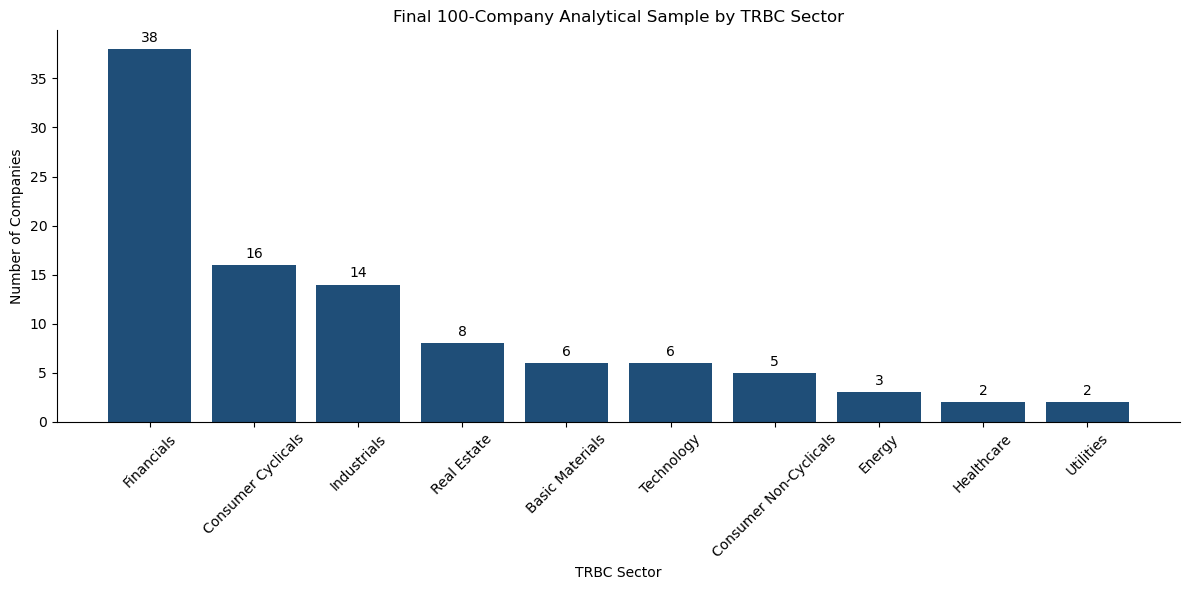

Chart saved as: Notebook02_Final_100_Sector_Distribution.png


In [17]:
final_sector_distribution = (
    final_100_df["TRBC Sector"]
    .value_counts()
    .reindex(sector_allocation["TRBC Sector"])
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    final_sector_distribution.index,
    final_sector_distribution.values,
    color=PROJECT_COLOUR
)

ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title("Final 100-Company Analytical Sample by TRBC Sector")
ax.set_xlabel("TRBC Sector")
ax.set_ylabel("Number of Companies")
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

chart_file = (
    OUTPUT_FOLDER / "Notebook02_Final_100_Sector_Distribution.png"
)

plt.savefig(chart_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Chart saved as: {chart_file.name}")

## 14. Conduct the Final Notebook Audit

I will perform a final audit of the 100-company sample by checking company uniqueness, report eligibility, file availability, word-count compliance, duplicate PDF hashes, missing values and sector-allocation accuracy. I will then export the complete Notebook 2 audit workbook.


In [18]:
key_columns = [
    "Final Sample ID",
    "Company Name",
    "TRBC Sector",
    "Report Year",
    "Report Type",
    "Text File Path",
    "Processed Text Path"
]

selected_sector_counts = (
    final_100_df["TRBC Sector"]
    .value_counts()
    .rename_axis("TRBC Sector")
    .reset_index(name="Selected Companies")
)

sector_validation = (
    sector_allocation[
        ["TRBC Sector", "Final Allocation"]
    ]
    .merge(
        selected_sector_counts,
        on="TRBC Sector",
        how="left"
    )
)

sector_validation["Selected Companies"] = (
    sector_validation["Selected Companies"]
    .fillna(0)
    .astype(int)
)

sector_validation["Allocation Matched"] = (
    sector_validation["Final Allocation"]
    == sector_validation["Selected Companies"]
)

duplicate_hashes = (
    final_100_df["Actual SHA256"].duplicated().sum()
    if "Actual SHA256" in final_100_df.columns
    else 0
)

audit_results = pd.DataFrame({
    "Audit Check": [
        "Final sample contains 100 companies",
        "Company names are unique",
        "Raw text files exist",
        "Processed text files exist",
        "All reports contain at least 5,000 words",
        "No duplicate PDF hashes",
        "No missing values in required fields",
        "Sector allocation matched"
    ],
    "Result": [
        len(final_100_df),
        final_100_df["Company Name"].nunique(),
        final_100_df["Text File Path"].apply(
            lambda path: Path(str(path)).is_file()
        ).sum(),
        final_100_df["Processed Text Path"].apply(
            lambda path: Path(str(path)).is_file()
        ).sum(),
        final_100_df["Extracted Word Count"].ge(MIN_WORDS).sum(),
        duplicate_hashes,
        int(final_100_df[key_columns].isna().sum().sum()),
        sector_validation["Allocation Matched"].sum()
    ],
    "Status": [
        "Passed" if len(final_100_df) == 100 else "Failed",
        "Passed" if final_100_df["Company Name"].nunique() == 100 else "Failed",
        "Passed" if final_100_df["Text File Path"].apply(
            lambda path: Path(str(path)).is_file()
        ).all() else "Failed",
        "Passed" if final_100_df["Processed Text Path"].apply(
            lambda path: Path(str(path)).is_file()
        ).all() else "Failed",
        "Passed" if final_100_df["Extracted Word Count"].ge(MIN_WORDS).all()
        else "Failed",
        "Passed" if duplicate_hashes == 0 else "Failed",
        "Passed" if final_100_df[key_columns].isna().sum().sum() == 0
        else "Failed",
        "Passed" if sector_validation["Allocation Matched"].all()
        else "Failed"
    ]
})

audit_file = DATA_FOLDER / "Notebook02_Final_Audit.xlsx"

with pd.ExcelWriter(audit_file, engine="openpyxl") as writer:
    audit_results.to_excel(
        writer,
        sheet_name="Audit Summary",
        index=False
    )
    sector_validation.to_excel(
        writer,
        sheet_name="Sector Validation",
        index=False
    )
    final_100_df.to_excel(
        writer,
        sheet_name="Final 100 Companies",
        index=False
    )

display(audit_results.style.hide(axis="index"))

if not audit_results["Status"].eq("Passed").all():
    raise ValueError("Notebook 2 audit failed. Review the failed checks.")

print("Notebook 2 final audit passed.")
print(f"Audit workbook saved as: {audit_file.name}")
print("The dataset is ready for NLP feature engineering in Notebook 3.")

Audit Check,Result,Status
Final sample contains 100 companies,100,Passed
Company names are unique,100,Passed
Raw text files exist,100,Passed
Processed text files exist,100,Passed
"All reports contain at least 5,000 words",100,Passed
No duplicate PDF hashes,0,Passed
No missing values in required fields,0,Passed
Sector allocation matched,10,Passed


Notebook 2 final audit passed.
Audit workbook saved as: Notebook02_Final_Audit.xlsx
The dataset is ready for NLP feature engineering in Notebook 3.


## 15. Visualise the Document Processing Flow

I will summarise the number of reports retained at each validation, extraction and preprocessing stage. This provides a clear audit trail from the reports collected in Notebook 1 to the final 100-company sample.


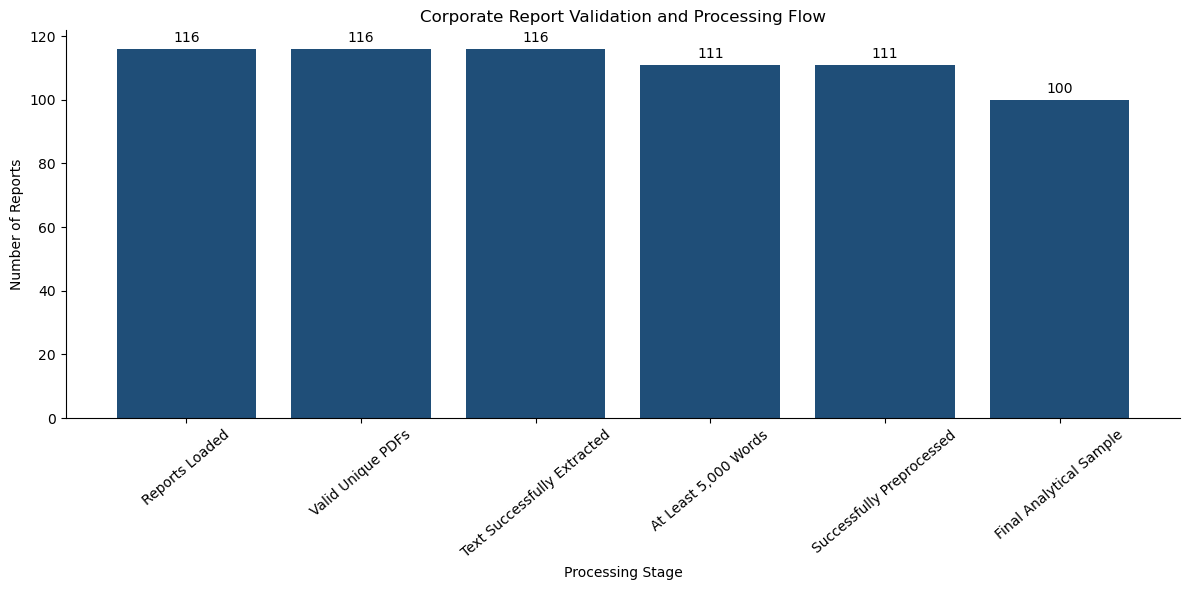

Chart saved as: Notebook02_Report_Processing_Flow.png


In [19]:
processing_flow = pd.DataFrame({
    "Processing Stage": [
        "Reports Loaded",
        "Valid Unique PDFs",
        "Text Successfully Extracted",
        "At Least 5,000 Words",
        "Successfully Preprocessed",
        "Final Analytical Sample"
    ],
    "Reports": [
        len(reports_df),
        len(pdf_eligible_df),
        extraction_df["Extraction Status"].eq("Successful").sum(),
        len(usable_reports_df),
        len(preprocessed_eligible_df),
        len(final_100_df)
    ]
})

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    processing_flow["Processing Stage"],
    processing_flow["Reports"],
    color=PROJECT_COLOUR
)

ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title("Corporate Report Validation and Processing Flow")
ax.set_xlabel("Processing Stage")
ax.set_ylabel("Number of Reports")
ax.tick_params(axis="x", rotation=40)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

flow_chart_file = (
    OUTPUT_FOLDER / "Notebook02_Report_Processing_Flow.png"
)

plt.savefig(flow_chart_file, dpi=300, bbox_inches="tight")
plt.show()

processing_flow.to_excel(
    DATA_FOLDER / "Notebook02_Report_Processing_Flow.xlsx",
    index=False
)

print(f"Chart saved as: {flow_chart_file.name}")

## Notebook Summary and Reproducibility Note

In this notebook, I validated the corporate reports collected in Notebook 1 by checking their file availability, PDF structure, completion status and SHA-256 hashes. I removed duplicate or invalid PDF files before extracting the report text.

I saved each successfully extracted report permanently in the `report/extracted_text` folder. I then assessed report eligibility using a minimum threshold of 5,000 extracted words. Eligible texts were cleaned, tokenised, filtered for stop words and lemmatised, with the processed versions saved in the `report/processed_text` folder.

I selected the final 100-company analytical sample using proportionate stratified sampling across the available TRBC sectors. A fixed random seed of 42 was used to make the selection reproducible. The final audit confirmed that the sample contained 100 unique companies, valid raw and processed text files, no duplicate PDF hashes, no missing required values and the correct sector allocations.

The following principal files were produced:

- `Notebook02_Text_Extraction_Register.xlsx`
- `Notebook02_Text_Eligibility_Audit.xlsx`
- `Notebook02_Preprocessed_Report_Register.xlsx`
- `Notebook02_Final_Processing_Audit.xlsx`
- `Notebook02_Final_100_Sector_Allocation.xlsx`
- `Notebook02_Final_Audit.xlsx`
- `Notebook03_Final_100_Text_Dataset.xlsx`
- `Notebook02_Final_100_Sector_Distribution.png`
- `Notebook02_Report_Processing_Flow.png`

The dataset is now ready for Notebook 3, where I will calculate the eight NLP features, conduct supporting TF-IDF analysis, construct the automated Reporting Quality Index and prepare the final analytical dataset.
